CUDA is available. Installing torch-geometric with CUDA support.
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 14.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for torch_scatter: filename=torch_scatter-2.1.2-cp312-cp312-linux_x86_64.whl size=3877463 sha256=13551400c3b36787ca42687a32ffb646db798c5790c88023e20a882e937ece7f
  Stored in directory: /root/.cache/pip/wheels/84/20/50/44800723f57cd798630e77b3ec83bc80bd26a1e3dc3a672ef5
  Created wheel for torch_sparse: filename=torch_sparse-0.6.18-cp312-cp312-linux_x86_64.whl size=3118693 sha256=88329b39912a5a3d759f0d156192209fe14cf3389993162f9ff05d730a680228
  Stored in directory: /root/.cache/pip/wheels/71/fa/21/bd1d78ce1629aec4ecc924a63b82f6949dda484b6321eac6f2
Successfully built torch_scatter torch_sparse
     ━━━━

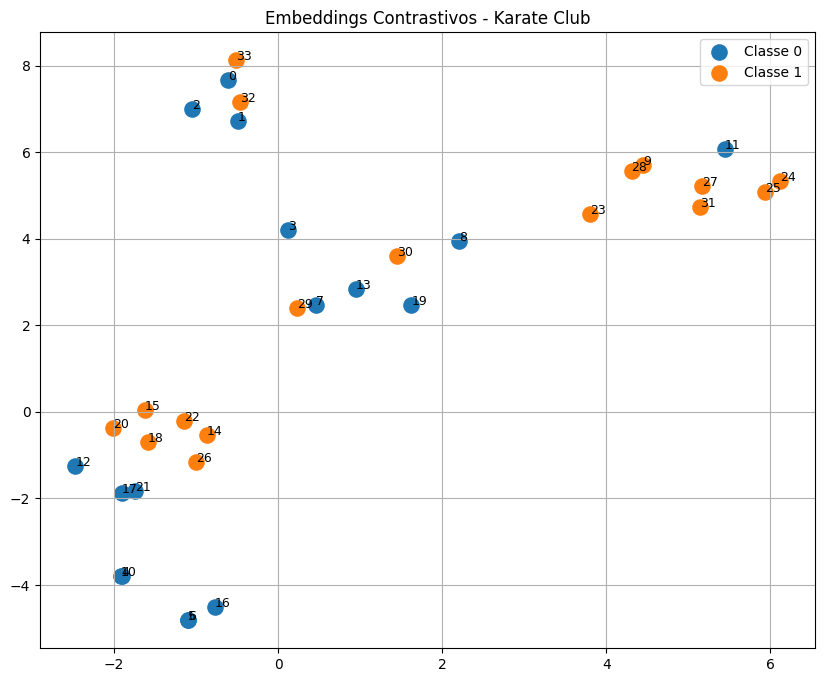

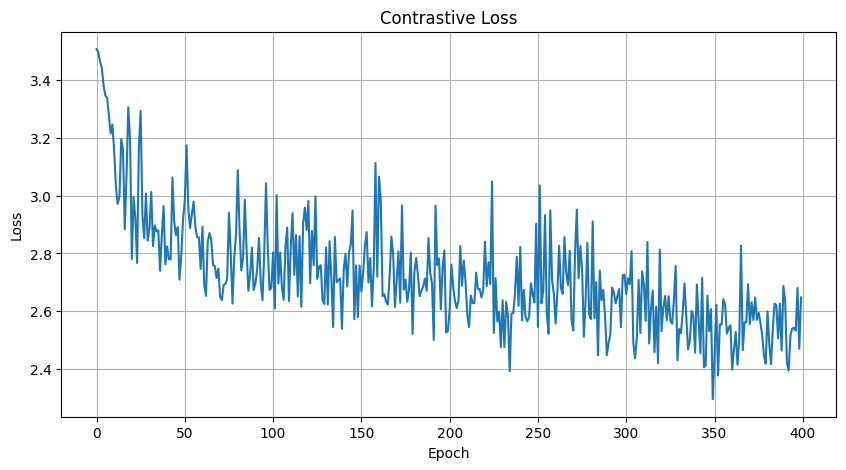


Testando robustez...

Ruído=0.0 | NMI=0.0422
Ruído=0.1 | NMI=0.0688
Ruído=0.2 | NMI=0.0688
Ruído=0.3 | NMI=0.0062
Ruído=0.4 | NMI=0.0062


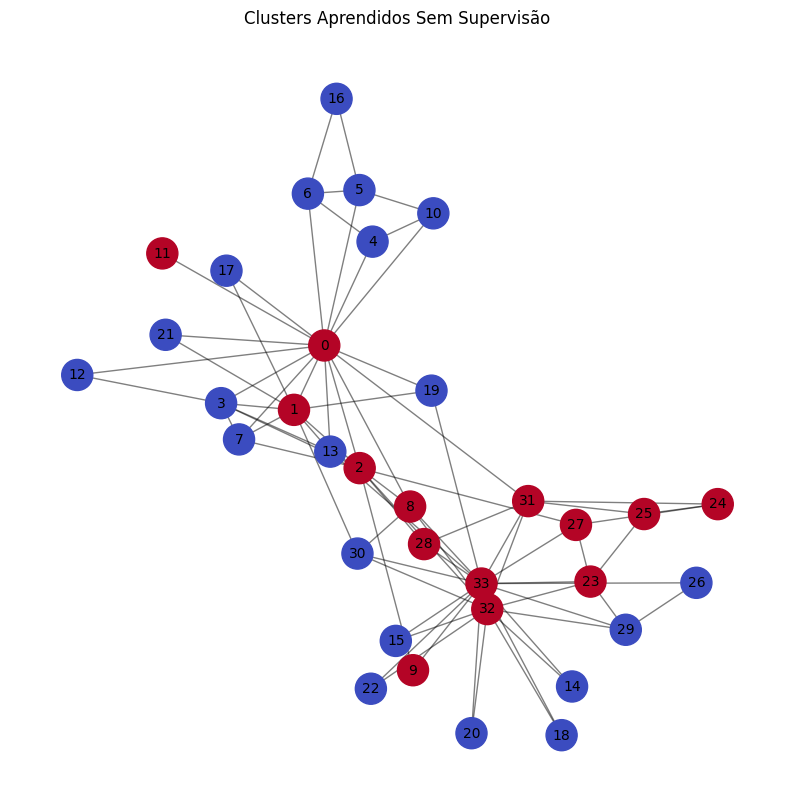


Treinando Deep Graph Infomax...

DGI Epoch 000 | Loss: 1.4611
DGI Epoch 050 | Loss: 0.9550
DGI Epoch 100 | Loss: 0.7739
DGI Epoch 150 | Loss: 0.6412
DGI Epoch 200 | Loss: 0.4193
DGI Epoch 250 | Loss: 0.6040


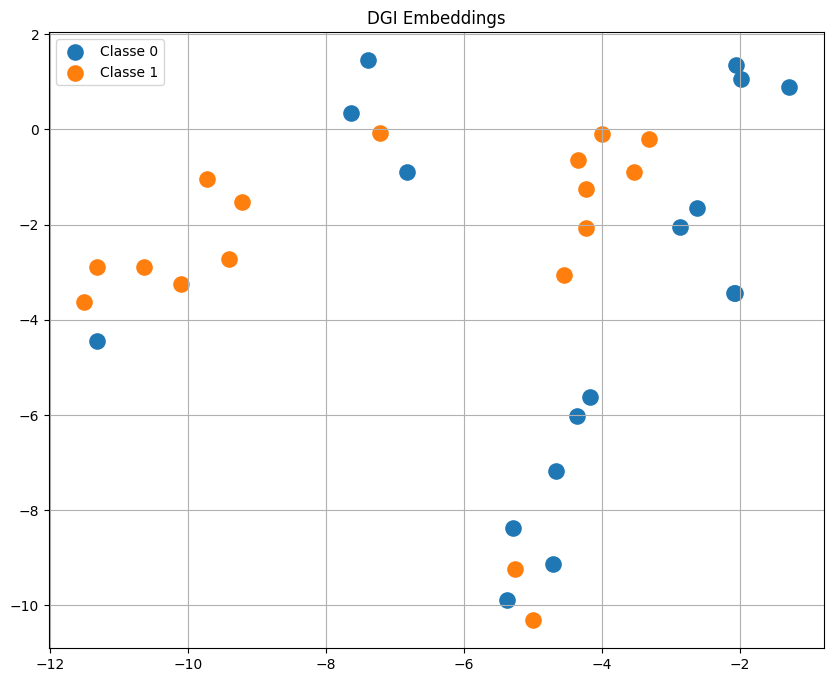


Projeto concluído.



In [ ]:
import torch

def install_torch_geometric():
    if torch.cuda.is_available():
        print("CUDA is available. Installing torch-geometric with CUDA support.")
        # Get CUDA version
        cuda_version = torch.version.cuda
        if cuda_version is None:
             # Fallback for some environments where torch.version.cuda might be None
            print("Could not detect CUDA version from torch.version.cuda, attempting default CUDA 11.8 install.")
            cuda_version = "11.8"
        elif cuda_version.startswith("12."):
            cuda_version = "12.1"
        elif cuda_version.startswith("11."):
            cuda_version = "11.8"
        else:
            print(f"Unsupported CUDA version {cuda_version}. Defaulting to CUDA 11.8.")
            cuda_version = "11.8"

        TORCH = torch.__version__.split('+')[0]

        # Install torch_scatter, torch_sparse, and torch_geometric with CUDA support
        !pip install torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-{TORCH}+cu{cuda_version.replace('.', '')}.html
        !pip install torch_geometric
    else:
        print("CUDA is not available. Installing torch-geometric for CPU.")
        !pip install torch_scatter torch_sparse torch_geometric

install_torch_geometric()


# ============================================================
# Projeto: Graph Contrastive Learning no Zachary Karate Club
# ============================================================
#
# Objetivo:
# Aprender embeddings de nós SEM rótulos usando
# Contrastive Learning em Grafos.
#
# Técnicas:
# - GraphCL
# - Deep Graph Infomax (DGI)
#
# Dataset:
# - Zachary Karate Club
#
# O projeto:
# 1. Cria duas views do grafo
# 2. Faz augmentations:
#       - Edge Dropping
#       - Feature Perturbation
# 3. Aprende embeddings contrastivos
# 4. Avalia:
#       - Visualização TSNE
#       - Clusterização
#       - Robustez a ruído
#
# ============================================================

import copy
import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score

from torch_geometric.utils import from_networkx
from torch_geometric.nn import GCNConv

# ============================================================
# CONFIG
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EMBED_DIM = 64
HIDDEN_DIM = 128
EPOCHS = 400
LR = 1e-3

EDGE_DROP_RATE = 0.2
FEATURE_DROP_RATE = 0.2

# ============================================================
# LOAD DATASET
# ============================================================

G = nx.karate_club_graph()

# Labels reais (somente para avaliação)
labels = []

for i in range(G.number_of_nodes()):
    club = G.nodes[i]["club"]

    if club == "Mr. Hi":
        labels.append(0)
    else:
        labels.append(1)

labels = torch.tensor(labels)

# ============================================================
# FEATURE ENGINEERING
# ============================================================

# Features simples:
# - Grau
# - Clustering coefficient
# - Pagerank
# - Betweenness

degrees = dict(G.degree())
clustering = nx.clustering(G)
pagerank = nx.pagerank(G)
betweenness = nx.betweenness_centrality(G)

features = []

for i in G.nodes():

    feat = [
        degrees[i],
        clustering[i],
        pagerank[i],
        betweenness[i]
    ]

    features.append(feat)

x = torch.tensor(features, dtype=torch.float)

# Normalização
x = (x - x.mean(0)) / (x.std(0) + 1e-8)

# ============================================================
# CONVERTER PARA PYG
# ============================================================

data = from_networkx(G)
data.x = x
data.y = labels

data = data.to(DEVICE)

# ============================================================
# AUGMENTATIONS
# ============================================================

def edge_drop(edge_index, drop_prob=0.2):

    E = edge_index.size(1)

    mask = torch.rand(E, device=edge_index.device) > drop_prob

    return edge_index[:, mask]


def feature_drop(x, drop_prob=0.2):

    mask = torch.rand_like(x) > drop_prob

    return x * mask


def graph_augment(data):

    aug_data = copy.deepcopy(data)

    aug_data.edge_index = edge_drop(
        aug_data.edge_index,
        EDGE_DROP_RATE
    )

    aug_data.x = feature_drop(
        aug_data.x,
        FEATURE_DROP_RATE
    )

    return aug_data

# ============================================================
# GCN ENCODER
# ============================================================

class GCNEncoder(nn.Module):

    def __init__(self, in_dim, hidden_dim, out_dim):

        super().__init__()

        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_dim)

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)

        return x

# ============================================================
# GRAPHCL MODEL
# ============================================================

class GraphCL(nn.Module):

    def __init__(self, encoder):

        super().__init__()

        self.encoder = encoder

        self.proj_head = nn.Sequential(
            nn.Linear(EMBED_DIM, EMBED_DIM),
            nn.ReLU(),
            nn.Linear(EMBED_DIM, EMBED_DIM)
        )

    def forward(self, x, edge_index):

        h = self.encoder(x, edge_index)

        z = self.proj_head(h)

        return h, z

# ============================================================
# NT-XENT LOSS
# ============================================================

def contrastive_loss(z1, z2, temperature=0.5):

    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    similarity = torch.mm(z1, z2.t())

    positives = torch.diag(similarity)

    numerator = torch.exp(positives / temperature)

    denominator = torch.sum(
        torch.exp(similarity / temperature),
        dim=1
    )

    loss = -torch.log(numerator / denominator)

    return loss.mean()

# ============================================================
# MODEL
# ============================================================

encoder = GCNEncoder(
    in_dim=data.x.size(1),
    hidden_dim=HIDDEN_DIM,
    out_dim=EMBED_DIM
)

model = GraphCL(encoder).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR
)

# ============================================================
# TRAINING
# ============================================================

print("\nTreinando Graph Contrastive Learning...\n")

losses = []

for epoch in range(EPOCHS):

    model.train()

    aug1 = graph_augment(data)
    aug2 = graph_augment(data)

    _, z1 = model(aug1.x, aug1.edge_index)
    _, z2 = model(aug2.x, aug2.edge_index)

    loss = contrastive_loss(z1, z2)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 50 == 0:

        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")

# ============================================================
# EXTRACT EMBEDDINGS
# ============================================================

model.eval()

with torch.no_grad():

    embeddings, _ = model(data.x, data.edge_index)

embeddings = embeddings.cpu().numpy()

# ============================================================
# KMEANS EVAL
# ============================================================

kmeans = KMeans(
    n_clusters=2,
    random_state=SEED
)

preds = kmeans.fit_predict(embeddings)

nmi = normalized_mutual_info_score(
    labels.numpy(),
    preds
)

print("\nNMI Score:", round(nmi, 4))

# ============================================================
# TSNE VISUALIZATION
# ============================================================

tsne = TSNE(
    n_components=2,
    random_state=SEED,
    perplexity=10
)

emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))

for label in [0, 1]:

    idx = labels.numpy() == label

    plt.scatter(
        emb_2d[idx, 0],
        emb_2d[idx, 1],
        s=120,
        label=f"Classe {label}"
    )

for i in range(len(emb_2d)):

    plt.text(
        emb_2d[i, 0],
        emb_2d[i, 1],
        str(i),
        fontsize=9
    )

plt.title("Embeddings Contrastivos - Karate Club")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# LOSS CURVE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(losses)

plt.title("Contrastive Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)
plt.show()

# ============================================================
# ROBUSTEZ A RUÍDO
# ============================================================

print("\nTestando robustez...\n")

noise_levels = [0.0, 0.1, 0.2, 0.3, 0.4]

for noise in noise_levels:

    noisy_x = feature_drop(data.x, noise)

    with torch.no_grad():

        emb_noise, _ = model(
            noisy_x,
            data.edge_index
        )

    emb_noise = emb_noise.cpu().numpy()

    preds_noise = KMeans(
        n_clusters=2,
        random_state=SEED
    ).fit_predict(emb_noise)

    nmi_noise = normalized_mutual_info_score(
        labels.numpy(),
        preds_noise
    )

    print(
        f"Ruído={noise:.1f} | "
        f"NMI={nmi_noise:.4f}"
    )

# ============================================================
# VISUALIZAÇÃO DO GRAFO
# ============================================================

plt.figure(figsize=(10, 10))

pos = nx.spring_layout(G, seed=SEED)

node_colors = preds

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    cmap=plt.cm.coolwarm,
    node_size=500
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.5
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10
)

plt.title("Clusters Aprendidos Sem Supervisão")
plt.axis("off")
plt.show()

# ============================================================
# DGI (Deep Graph Infomax)
# ============================================================

class DGI(nn.Module):

    def __init__(self, encoder, hidden_dim):

        super().__init__()

        self.encoder = encoder

        self.readout = nn.Linear(hidden_dim, hidden_dim)

    def corruption(self, x):

        idx = torch.randperm(x.size(0))

        return x[idx]

    def summary(self, h):

        return torch.sigmoid(h.mean(dim=0))

    def discriminate(self, h, s):

        return torch.matmul(h, s)

    def forward(self, x, edge_index):

        h_pos = self.encoder(x, edge_index)

        x_corrupt = self.corruption(x)

        h_neg = self.encoder(x_corrupt, edge_index)

        s = self.summary(h_pos)

        pos_scores = self.discriminate(h_pos, s)
        neg_scores = self.discriminate(h_neg, s)

        return pos_scores, neg_scores

# ============================================================
# TREINO DGI
# ============================================================

print("\nTreinando Deep Graph Infomax...\n")

dgi_encoder = GCNEncoder(
    in_dim=data.x.size(1),
    hidden_dim=HIDDEN_DIM,
    out_dim=EMBED_DIM
)

dgi_model = DGI(
    dgi_encoder,
    EMBED_DIM
).to(DEVICE)

optimizer_dgi = torch.optim.Adam(
    dgi_model.parameters(),
    lr=LR
)

for epoch in range(300):

    dgi_model.train()

    pos_scores, neg_scores = dgi_model(
        data.x,
        data.edge_index
    )

    pos_loss = F.binary_cross_entropy_with_logits(
        pos_scores,
        torch.ones_like(pos_scores)
    )

    neg_loss = F.binary_cross_entropy_with_logits(
        neg_scores,
        torch.zeros_like(neg_scores)
    )

    loss = pos_loss + neg_loss

    optimizer_dgi.zero_grad()
    loss.backward()
    optimizer_dgi.step()

    if epoch % 50 == 0:

        print(
            f"DGI Epoch {epoch:03d} | "
            f"Loss: {loss.item():.4f}"
        )

# ============================================================
# EMBEDDINGS DGI
# ============================================================

dgi_model.eval()

with torch.no_grad():

    dgi_embeddings = dgi_encoder(
        data.x,
        data.edge_index
    )

dgi_embeddings = dgi_embeddings.cpu().numpy()

# ============================================================
# TSNE DGI
# ============================================================

tsne = TSNE(
    n_components=2,
    random_state=SEED,
    perplexity=10
)

dgi_2d = tsne.fit_transform(dgi_embeddings)

plt.figure(figsize=(10, 8))

for label in [0, 1]:

    idx = labels.numpy() == label

    plt.scatter(
        dgi_2d[idx, 0],
        dgi_2d[idx, 1],
        s=120,
        label=f"Classe {label}"
    )

plt.title("DGI Embeddings")
plt.legend()
plt.grid(True)
plt.show()

print("\nProjeto concluído.\n")